In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from main import McKeanVlasovSolver
from main import McKeanVlasovPlotter
import numpy as np
from scipy.special import beta

Functions definition

In [3]:
def G(x):
    return (x - np.pi)**2 # - 2 * (x - np.pi)**2 + 1

def alpha(x):
    return np.sin(x) + np.cos(x)

def nabla_alpha(x):
    return np.cos(x) - np.sin(x)

def W(x):
    return np.cos(x)

def mu_0(x):
    alpha_param = 2.0
    beta_param = 2.0
    Z = (2 * np.pi)**(alpha_param + beta_param - 1) * beta(alpha_param, beta_param)
    return (x**(alpha_param - 1) * (2 * np.pi - x)**(beta_param - 1)) / Z

def mu_0_mixed(x):
    alpha_param1 = 4.0
    beta_param1 = 2.0
    Z1 = (2 * np.pi)**(alpha_param1 + beta_param1 - 1) * beta(alpha_param1, beta_param1)

    alpha_param2 = 2.0
    beta_param2 = 10.0
    Z2 = (2 * np.pi)**(alpha_param2 + beta_param2 - 1) * beta(alpha_param2, beta_param2)
    return 0.5*(x**(alpha_param1 - 1) * (2 * np.pi - x)**(beta_param1 - 1)) / Z1 + 0.5*(x**(alpha_param2 - 1) * (2 * np.pi - x)**(beta_param2 - 1)) / Z2

Solver

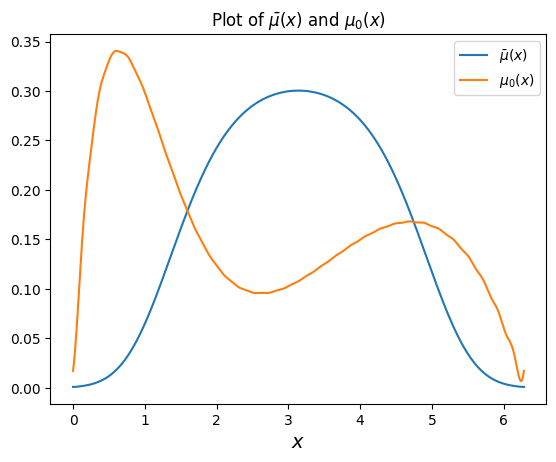

All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.05.
MESSAGE - Nonlinear equation solved in 0.17.


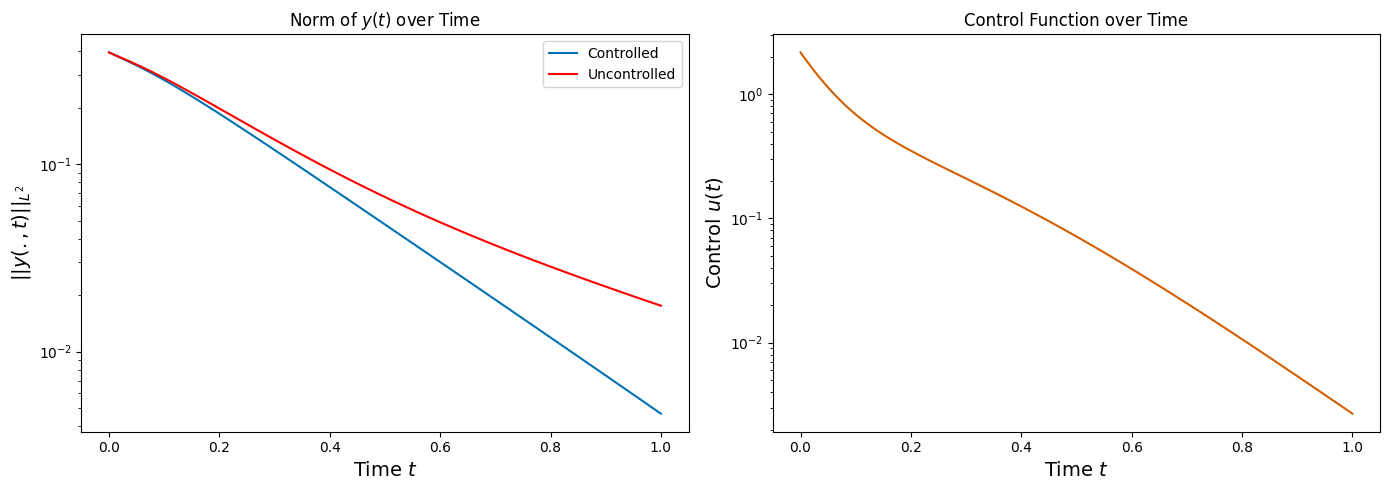

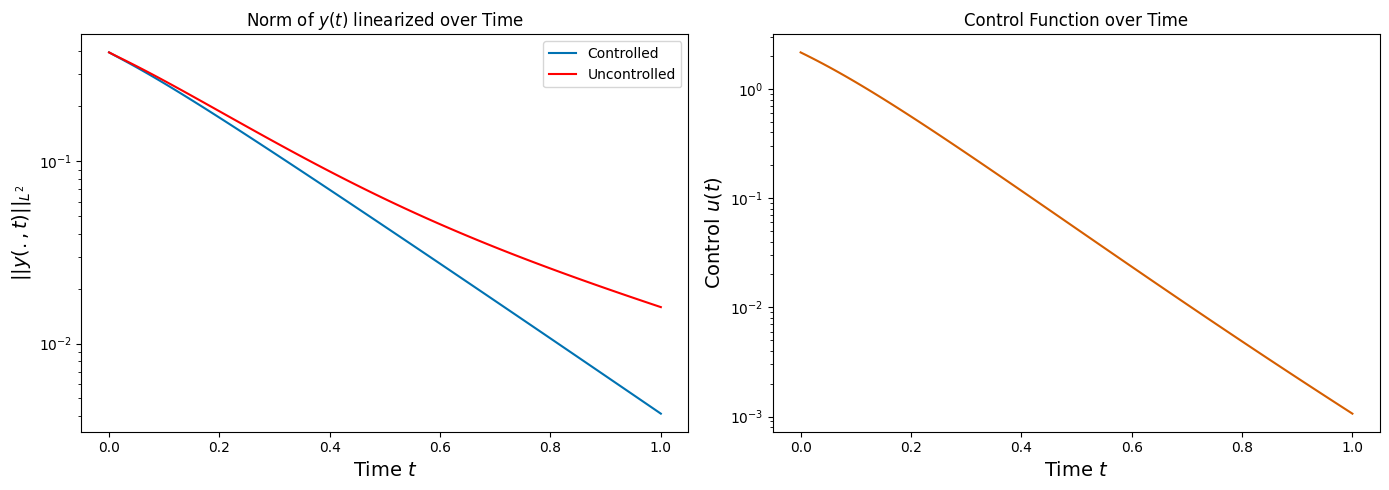

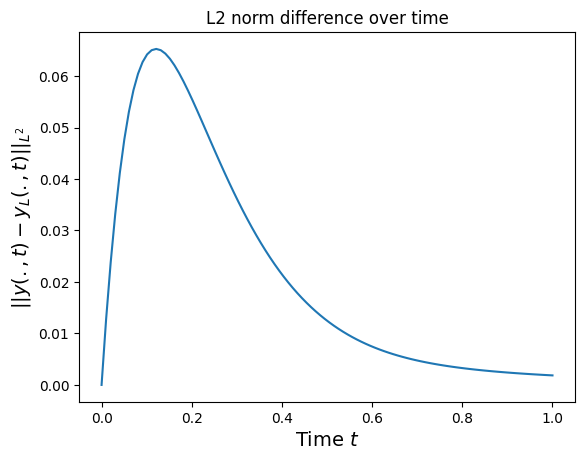

In [5]:
solver = McKeanVlasovSolver(L=30, d=2*np.pi, G=G, alpha=alpha, W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha="constant", state_weight=1000)
plotter = McKeanVlasovPlotter(solver)

plotter.plot_mu_bar_x()
plotter.plot_control_and_norm(t_max=1.0)
plotter.plot_control_and_norm_linear(t_max=1.0)
plotter.plot_y_diff_L2_norm(t_max=1.0)

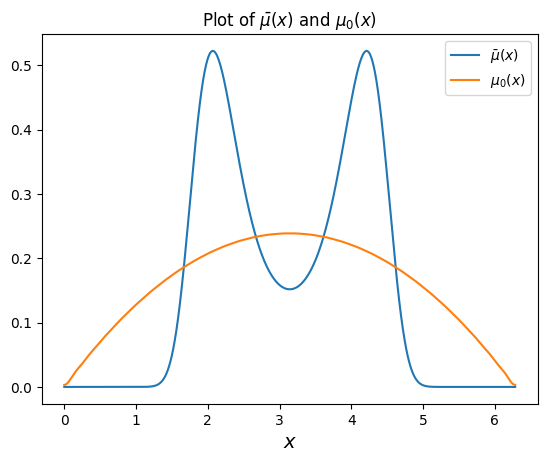

All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.04.
MESSAGE - Nonlinear equation solved in 0.31.


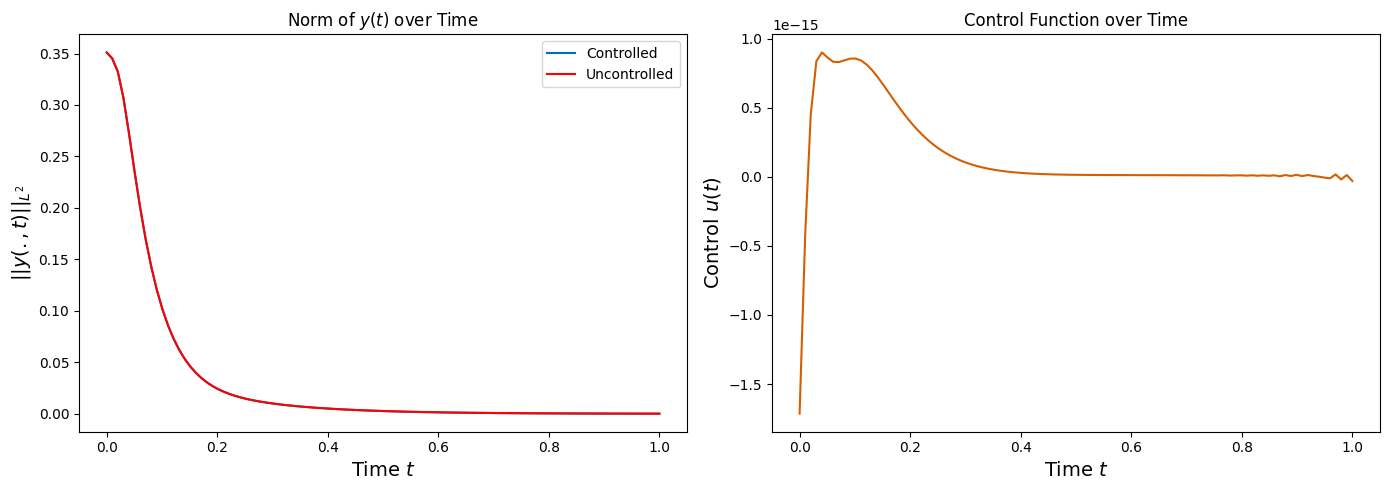

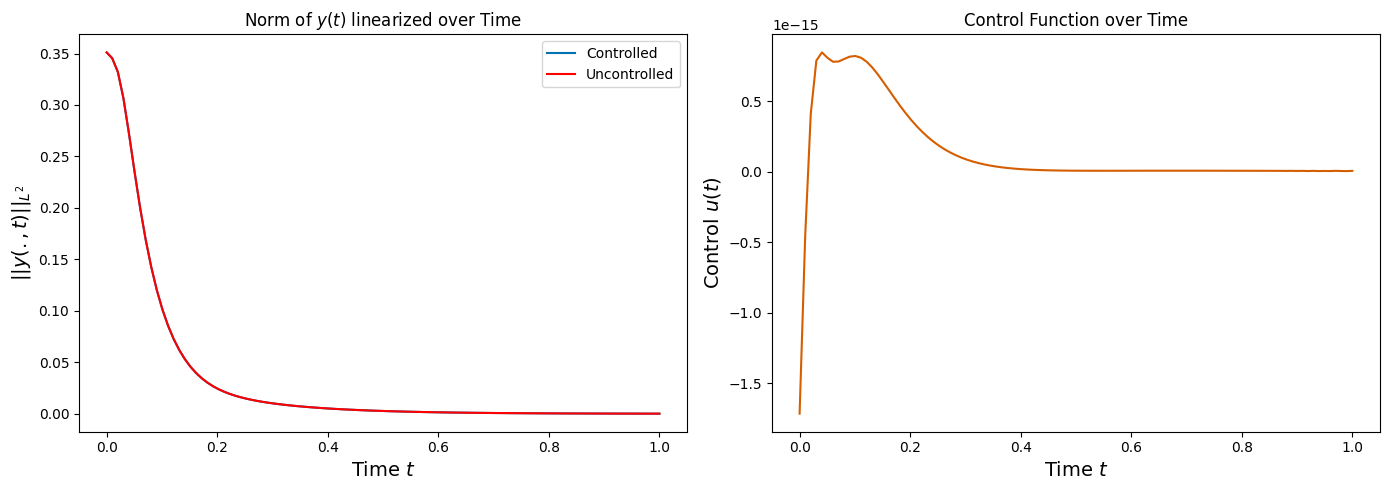

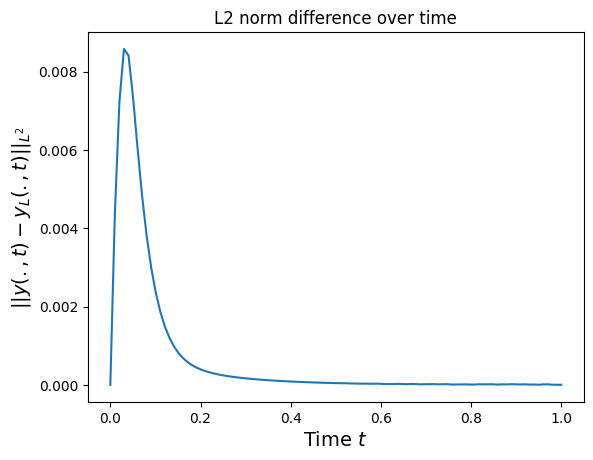

In [26]:
solver = McKeanVlasovSolver(L=30, d=2*np.pi, G=G, alpha=alpha, W=W, mu_0=mu_0, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha="constant", state_weight=100)
plotter = McKeanVlasovPlotter(solver)

plotter.plot_mu_bar_x()
plotter.plot_control_and_norm(t_max=1.0)
plotter.plot_control_and_norm_linear(t_max=1.0)
plotter.plot_y_diff_L2_norm(t_max=1.0)

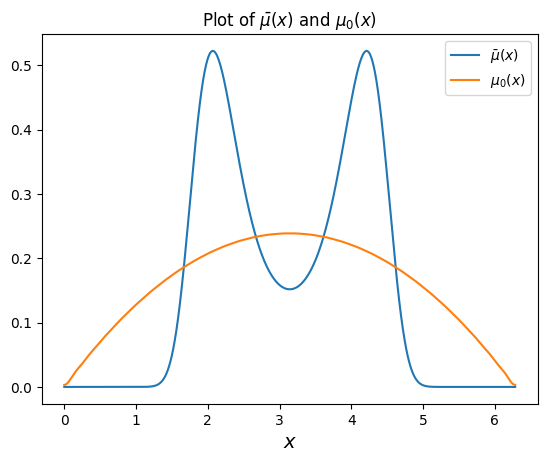

All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.05.
MESSAGE - Nonlinear equation solved in 0.28.


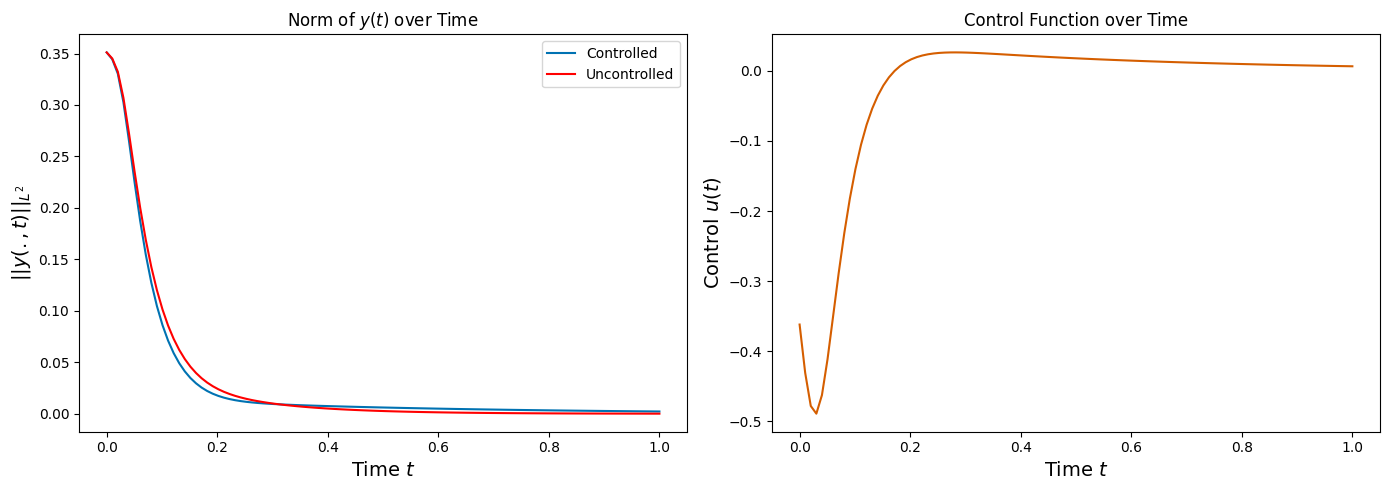

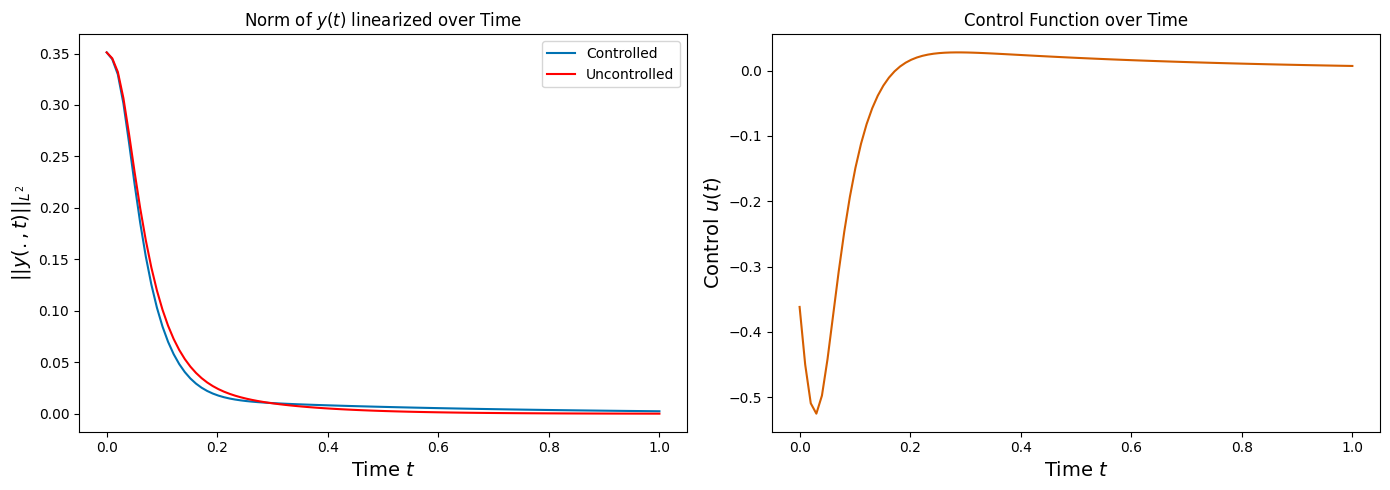

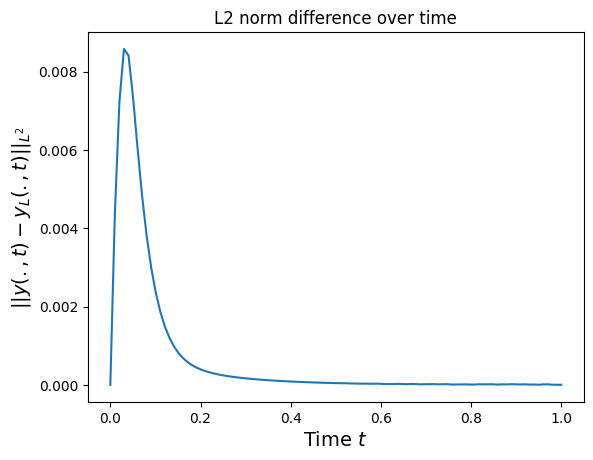

In [22]:
solver = McKeanVlasovSolver(L=30, d=2*np.pi, G=G, alpha=alpha, W=W, mu_0=mu_0, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=nabla_alpha, state_weight=100)
plotter = McKeanVlasovPlotter(solver)

plotter.plot_mu_bar_x()
plotter.plot_control_and_norm(t_max=1.0)
plotter.plot_control_and_norm_linear(t_max=1.0)
plotter.plot_y_diff_L2_norm(t_max=1.0)

- Work with u(x,t) = sum u_i(t) phi_i(x).

In [ ]:
def G(x):
    return np.cos(x/(2*np.pi)) # - 2 * (x - np.pi)**2 + 1

def alpha(x):
    return np.sin(x) + np.cos(x)

def nabla_alpha(x):
    return np.cos(x) - np.sin(x)

def W(x):
    return np.cos(x/(2*np.pi))

def mu_0(x):
    alpha_param = 2.0
    beta_param = 2.0
    Z = (2 * np.pi)**(alpha_param + beta_param - 1) * beta(alpha_param, beta_param)
    return (x**(alpha_param - 1) * (2 * np.pi - x)**(beta_param - 1)) / Z

def mu_0_mixed(x):
    alpha_param1 = 4.0
    beta_param1 = 2.0
    Z1 = (2 * np.pi)**(alpha_param1 + beta_param1 - 1) * beta(alpha_param1, beta_param1)

    alpha_param2 = 2.0
    beta_param2 = 10.0
    Z2 = (2 * np.pi)**(alpha_param2 + beta_param2 - 1) * beta(alpha_param2, beta_param2)
    return 0.5*(x**(alpha_param1 - 1) * (2 * np.pi - x)**(beta_param1 - 1)) / Z1 + 0.5*(x**(alpha_param2 - 1) * (2 * np.pi - x)**(beta_param2 - 1)) / Z2